In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime as dt

In [3]:
start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,28)

stk_data = yf.download("RELIANCE.NS", start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [4]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-07-01,954.592468,966.058736,953.250158,963.715439,12534407
2021-07-02,968.743286,970.495102,952.317341,954.160145,14086620
2021-07-05,978.366882,979.891169,969.858139,972.110448,11702287
2021-07-06,966.809570,977.775346,964.716550,975.978096,10070124
2021-07-07,960.098145,968.151889,954.615287,968.151889,10454892
...,...,...,...,...,...
2022-01-20,1127.269531,1142.057456,1117.054466,1137.552838,16494486
2022-01-21,1127.451538,1138.553855,1115.689559,1115.689559,13338594


In [5]:
# The dataframe is not normal columns, it’s a MultiIndex (two-level columns).
# So, flattening the columns:

stk_data.columns = stk_data.columns.get_level_values(0)

In [6]:
stk_data

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-07-01,954.592468,966.058736,953.250158,963.715439,12534407
2021-07-02,968.743286,970.495102,952.317341,954.160145,14086620
2021-07-05,978.366882,979.891169,969.858139,972.110448,11702287
2021-07-06,966.809570,977.775346,964.716550,975.978096,10070124
2021-07-07,960.098145,968.151889,954.615287,968.151889,10454892
...,...,...,...,...,...
2022-01-20,1127.269531,1142.057456,1117.054466,1137.552838,16494486
2022-01-21,1127.451538,1138.553855,1115.689559,1115.689559,13338594
2022-01-24,1081.973145,1139.691425,1071.598850,1126.154703,21868937


In [7]:
stk_data=stk_data[["Open", "High", "Low", "Close"]]

In [8]:
stk_data

Price,Open,High,Low,Close
Date,,,,
2021-07-01,963.715439,966.058736,953.250158,954.592468
2021-07-02,954.160145,970.495102,952.317341,968.743286
2021-07-05,972.110448,979.891169,969.858139,978.366882
2021-07-06,975.978096,977.775346,964.716550,966.809570
2021-07-07,968.151889,968.151889,954.615287,960.098145
...,...,...,...,...
2022-01-20,1137.552838,1142.057456,1117.054466,1127.269531
2022-01-21,1115.689559,1138.553855,1115.689559,1127.451538
2022-01-24,1126.154703,1139.691425,1071.598850,1081.973145


In [9]:
column="Close"

In [10]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1 = Ms.fit_transform(stk_data[[column]])
print("Len:", data1.shape)

Len: (144, 1)


In [11]:
len(data1)

144

### Train - Test Split

In [12]:
training_size = round(len(data1) * 0.95)
print(training_size)

X_train = data1[:training_size]
X_test = data1[training_size:]
print("X_train length:", X_train.shape)
print("X_test length:", X_test.shape)

y_train = data1[:training_size]
y_test = data1[training_size:]
print("y_train length:", y_train.shape)
print("y_test length:", y_test.shape)

137
X_train length: (137, 1)
X_test length: (7, 1)
y_train length: (137, 1)
y_test length: (7, 1)


### Model Creation

#### ARIMA Model

In [13]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from stockFunctions import rmsemape  

orders = [(1,1,1), (1,1,2), (2,3,1), (2,2,2)]

for i in orders:
    from statsmodels.tsa.arima.model import ARIMA

    # Build model
    model = ARIMA(data1, order=i)
    model_fit = model.fit()

    # Make prediction
    y_pred = model_fit.predict(start=0, end=len(data1)-1)

    from stockFunctions import rmsemape
    print("Order:", i)
    rmsemape(data1, y_pred)
    print("************")

Order: (1, 1, 1)
RMSE-Testset: 0.052877345892509135
MAPE-Testset: 742294229994.4874
************
Order: (1, 1, 2)
RMSE-Testset: 0.05252975371305864
MAPE-Testset: 791657450168.7573
************
Order: (2, 3, 1)
RMSE-Testset: 0.06331458806371468
MAPE-Testset: 409696805268.31604
************
Order: (2, 2, 2)
RMSE-Testset: 0.05311979977922088
MAPE-Testset: 685146825670.4178
************


C:\Users\Default.DESKTOP-73FCCDO\Documents\Installations\envs\aiml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [14]:
len(y_pred)

144

In [15]:
from statsmodels.tsa.arima.model import ARIMA
from stockFunctions import rmsemape

# Best model
i = (2,2,2)

# Build model
model = ARIMA(data1, order=i)
model_fit = model.fit()

# Make prediction
y_pred = model_fit.predict(start=0, end=len(data1)-1)

# Print results
print("Order:", i)
rmsemape(data1, y_pred)
print("************")

Order: (2, 2, 2)
RMSE-Testset: 0.05311979977922088
MAPE-Testset: 685146825670.4178
************


C:\Users\Default.DESKTOP-73FCCDO\Documents\Installations\envs\aiml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


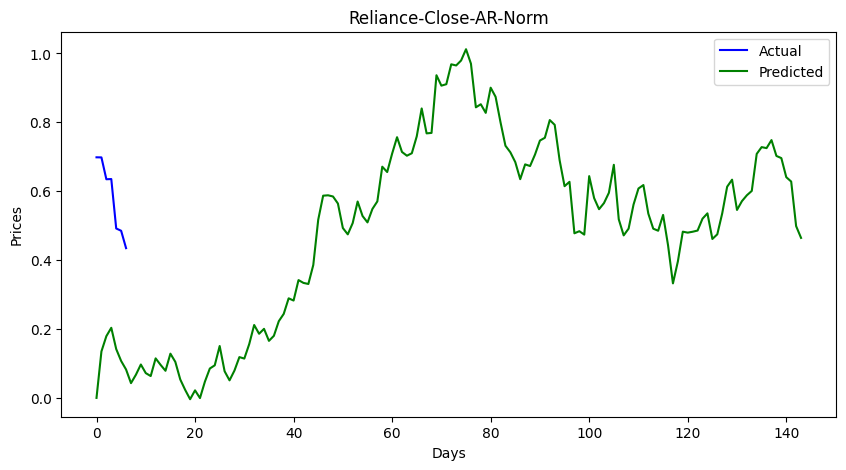

In [16]:
from stockFunctions import graph
graph(y_test, y_pred, "Actual", "Predicted", "Reliance-Close-AR-Norm", "Days", "Prices")

In [17]:
len(data1)

144

In [18]:
y_test

array([[0.69844249],
       [0.69815517],
       [0.63477144],
       [0.63534571],
       [0.49185292],
       [0.48517704],
       [0.43471371]])

### Coverting to original data

In [19]:
from stockFunctions import conversionSingle
aTestNormTable = conversionSingle(y_test, [column])

In [20]:
aTestNormTable

,Close
0,0.698442
1,0.698155
2,0.634771
3,0.635346
4,0.491853
5,0.485177
6,0.434714


In [21]:
actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)

In [22]:
actual_stock_price_test_ori

array([[1147.44934082],
       [1147.35827637],
       [1127.26953125],
       [1127.45153809],
       [1081.97314453],
       [1079.8572998 ],
       [1063.86352539]])

In [23]:
actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])

In [24]:
actual_stock_price_test_oriA

,Close
0,1147.449341
1,1147.358276
2,1127.269531
3,1127.451538
4,1081.973145
5,1079.8573
6,1063.863525


In [25]:
from stockFunctions import conversionSingle

aTestNormTable = conversionSingle(y_test, [column])
actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])

In [26]:
from stockFunctions import conversionSingle

pTestNormTable = conversionSingle(y_pred, [column])
predicted_stock_price_test_ori = Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP = conversionSingle(predicted_stock_price_test_ori, [column])

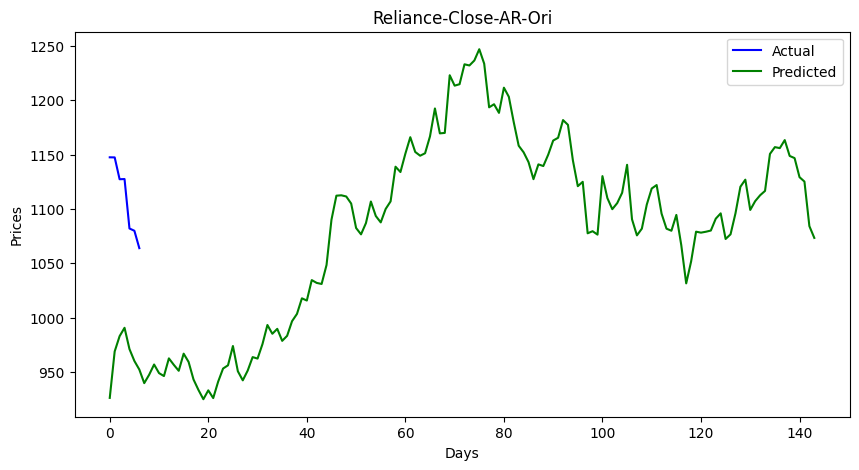

In [27]:
from stockFunctions import graph

graph(actual_stock_price_test_oriA,
      predicted_stock_price_test_oriP,
      "Actual",
      "Predicted",
      "Reliance-Close-AR-Ori",
      "Days",
      "Prices")

### Checking the model forcast

In [28]:
forecast = model_fit.predict(len(data1), len(data1)+3)

In [29]:
forecast

array([0.44860344, 0.43312224, 0.44567168, 0.43521624])

In [30]:
from stockFunctions import conversionSingle

fTestNormTable = conversionSingle(forecast, ["Closefore"])
forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF = conversionSingle(forecast_stock_price_test_ori, ["Closefore"])

In [31]:
forecast_stock_price_test_oriF

,Closefore
0,1068.265718
1,1063.359129
2,1067.336529
3,1064.022797


In [32]:
forecast_stock_price_test_oriF.to_csv("CloseARIMA.csv", index=False)

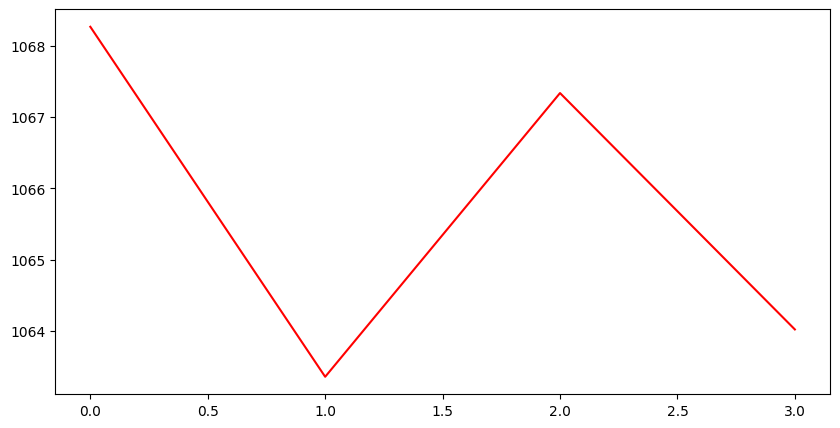

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[116:144], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label="Predicted")